In [17]:
import os
import sys

import numpy as np
from lmfit import minimize, Parameters, fit_report, Model
from tqdm import tqdm
import matplotlib.pyplot as plt
#from pfb_tools import DeconvolvePFB

from scipy import signal
from scipy.stats import median_abs_deviation
from scipy.interpolate import make_lsq_spline
import matplotlib

import json
from copy import deepcopy
import chime_frb_constants as const
import fitburst as fb
from scipy.interpolate import interp2d

from baseband_analysis.core.signal import get_main_peak_lim, tiedbeam_baseband_to_power
from baseband_analysis.core.bbdata import BBData
from baseband_analysis.analysis.snr import get_snr, get_profile
from baseband_analysis.core.sampling import scrunch
from baseband_analysis.core.dedispersion import coherent_dedisp, incoherent_dedisp
from baseband_analysis.analysis.polarization import get_burst_envelope

from chime_frb_constants import FPGA_DELTA_FREQ_MHZ, K_DM

from importlib import reload
import utilities.scint_utils
from utilities.scint_utils import deripple, fill_missing_chans, upchannel, upchannel_fast, \
                                    autocorr, autocorr_midx, make_scallop_model, bandpasscorr_channel, \
                                    acf_scint_plot, lorentz_withc_min, lorentz_w_c


import chime_frb_api
master = chime_frb_api.frb_master.FRBMaster(base_url = "https://frb.chimenet.ca/frb-master")
master.API.authorize()
auth = {"Authorization": master.API.access_token}


In [5]:
names = np.array([
'zach',
'whitney',
'oran',
'isha',
'wilhelm',
'phineas',
'freya',
'johndoeII'
'hamilton',
'mahi',
'chromatica',
'casey',
])

chimeids = np.array([
'210456524',
'215063905',
'224263996',
'252069198',
'253635173',
'274819243',
'278720455',
'311723353'
'318353610',
'354049284',
'356959136',
'362593221'
])

dir_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221'
])

file_paths = np.array([
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/02/07/astro_210456524/run_pre_apr2025/singlebeam_210456524.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/03/10/astro_215063905/run_pre_apr2025/singlebeam_215063905.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/05/06/astro_224263996/run_pre_apr2025/singlebeam_224263996.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/11/13/astro_252069198/run_pre_apr2025/singlebeam_252069198.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2022/12/03/astro_253635173/run_pre_apr2025/singlebeam_253635173.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/07/astro_274819243/singlebeam_274819243.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/03/25/astro_278720455/singlebeam_278720455.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/08/14/astro_311723353/singlebeam_311723353.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2023/09/13/astro_318353610/singlebeam_318353610.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/01/22/astro_354049284/singlebeam_354049284.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/03/astro_356959136/singlebeam_356959136.h5',
'/arc/projects/chime_frb/data/chime/baseband/processed/2024/02/29/astro_362593221/singlebeam_362593221.h5'
])

dms_opt = np.array([
262.368,
462.174,
396.882,
411.568,
602.346,
610.274,
912.400,
696.506,
518.799,
960.128,
272.664,
491.207,
])

In [6]:
event_idx = 0
downsample_factor = 1

In [12]:
rerun = False

In [14]:
if rerun:
    frb_bbdata = BBData.from_file(file_paths[event_idx])
    dm = dms_opt[event_idx]

    if "tiedbeam_power" not in list(frb_bbdata.keys()):
        tiedbeam_baseband_to_power(
            frb_bbdata, time_downsample_factor=1, dm=dm, dedisperse=True, time_shift=False
        )

    getsnr_output = get_snr(frb_bbdata,DM=dm,diagnostic_plots=True,return_full=True,downsample=downsample_factor,DM_range=None,spectrum_lim=False)

    coherent_dedisp(frb_bbdata, dm, time_shift=False,write=True)

    data_dedisp, freq, freq_id = incoherent_dedisp(frb_bbdata,dm,fill_wfall=False)

    #Null out invalid channels, determined by get_snr()
    valid_channels=getsnr_output[5]
    data_dedisp[~valid_channels] = 0
    data_dedisp = np.ma.masked_where(data_dedisp==0,data_dedisp)

    #keep only valid times as determined by get_snr
    timerange = getsnr_output[6]
    data_dedisp = data_dedisp[:,:,timerange[0]:timerange[1]]

    interactive=True
    time_range=None
    off=True
    zap_extra=True
    diagnostic_plot=True

    #let's now figure out what data we want to keep
    power=np.abs(data_dedisp)**2
    I = np.nansum(power,axis=1)
    Iscr=scrunch(I,tscrunch=downsample_factor,fscrunch=1)

    try:
        nanind=np.argwhere(np.isnan(Iscr[-1,:]))[0][0]
        Iscr=Iscr[:,:nanind]
    except:
        print('No NaNs to mask')

    if time_range is not None:
        answer=time_range
    else:
        if interactive==True:
            plt.close('all')
            plt.plot(np.nanmean(Iscr,axis=0))
            plt.show()
            plt.savefig('./temp.png')
            answer=input('Please define the time bin range to keep (beginbin,endbin): ')
            print(f'burst window: {answer}')
            answer = answer.split(',')
            answer = [int(i) for i in answer]
            if off==True:
                answer_off=[0,(answer[0]-10000)//downsample_factor]
        else:
            plt.close('all')
            lims=get_burst_envelope_kn(power, thres=6, pad=0, diagnostic_plots=diagnostic_plot)
            print(lims)
            answer=[(lims[0]-20000)//downsample_factor,(lims[1]+20000)//downsample_factor]
            if off==True:
                answer_off=[0,(lims[0]-10000)//downsample_factor]

    data_dedisp_masked, freqs, freq_id = fill_missing_chans(data_dedisp[:,:,int(answer[0])*downsample_factor:int(answer[1])*downsample_factor],frb_bbdata) 
    data_dedisp_masked_off, freqs_off, freq_id_off = fill_missing_chans(data_dedisp[:,:,int(answer_off[0])*downsample_factor:int(answer_off[1])*downsample_factor],frb_bbdata) 

    if zap_extra==True:
        #now let's try additional RFI zapping
        chan_spectrum = np.nansum( np.nansum(np.abs(data_dedisp_masked)**2,axis=1),axis=-1)
        chan_spectrum_snr = (chan_spectrum - np.nanmedian(chan_spectrum))
        chan_spectrum_snr /= (1.4826*median_abs_deviation(chan_spectrum,nan_policy='omit'))
        miss_chan_mask = np.where( (chan_spectrum_snr < -1) *(chan_spectrum > 0) )
        data_dedisp_masked[miss_chan_mask,:,:] = 0
        data_dedisp_masked_off[miss_chan_mask,:,:] = 0

        data_dedisp_masked = np.ma.masked_where(data_dedisp_masked==0,data_dedisp_masked)
        data_dedisp_masked_off = np.ma.masked_where(data_dedisp_masked_off==0,data_dedisp_masked_off)

    power=np.abs(data_dedisp_masked)**2
    power_off=np.abs(data_dedisp_masked_off)**2
    power_deripple=deripple(power, power_off)

    I = np.nansum(power_deripple,axis=1)
    
    np.savez('zach_power_xy_deripple.npz',
             data=power_deripple.data,
             mask=power_deripple.mask)
    
    np.savez('zach_I.npz',
             data=I.data,
             mask=I.mask)
else:
    pass


In [15]:
power_xy_womask = np.load('zach_power_xy_deripple.npz')
power_xy = np.ma.MaskedArray(power_xy_womask['data'], mask=power_xy_womask['mask'])

I_womask = np.load('zach_I.npz')
I = np.ma.MaskedArray(I_womask['data'], mask=I_womask['mask'])

print(power_xy.shape)
print(I.shape)

In [18]:
reload(utilities.scint_utils)

<module 'utilities.scint_utils' from '/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/scintillation/utilities/scint_utils.py'>

In [152]:
fftsize=64
downfreq=1

power_upchan, power_freqs, power_freqids = upchannel(power_deripple,freq_id,fftsize=fftsize,downfreq=downfreq)

In [156]:
print(power_upchan.shape)

(2, 187, 65536)


In [157]:
off_pulse_idx = np.arange(0, 50)
scallop_model, spec_noise_masked_corr, sallop_ids = make_scallop_model(power_upchan[:, off_pulse_idx, :], fftsize=fftsize, downfreq=downfreq)

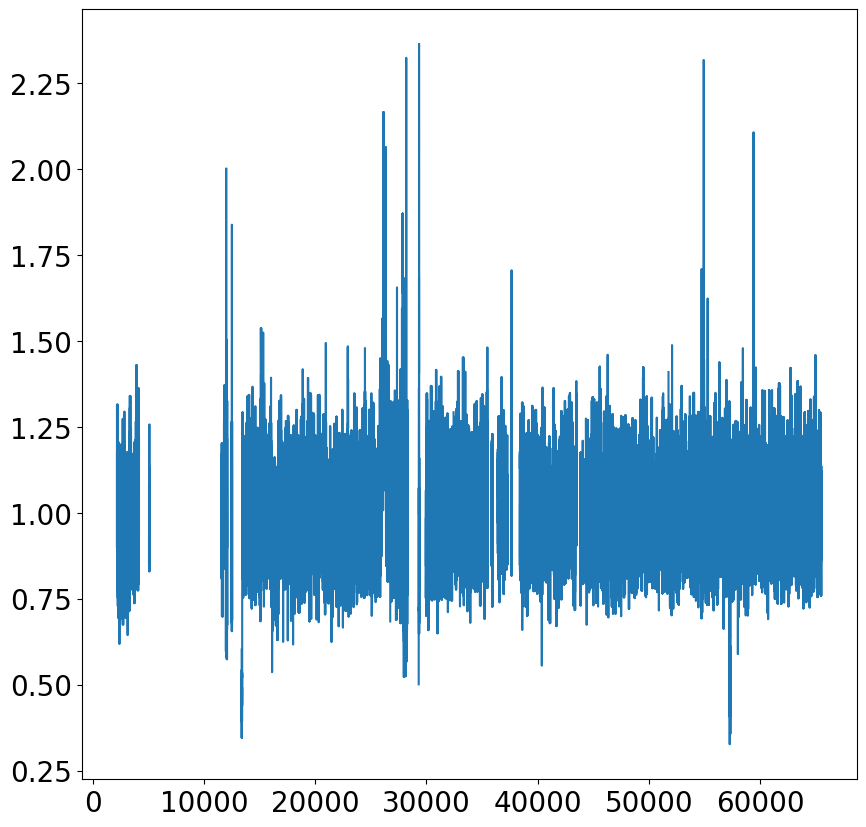

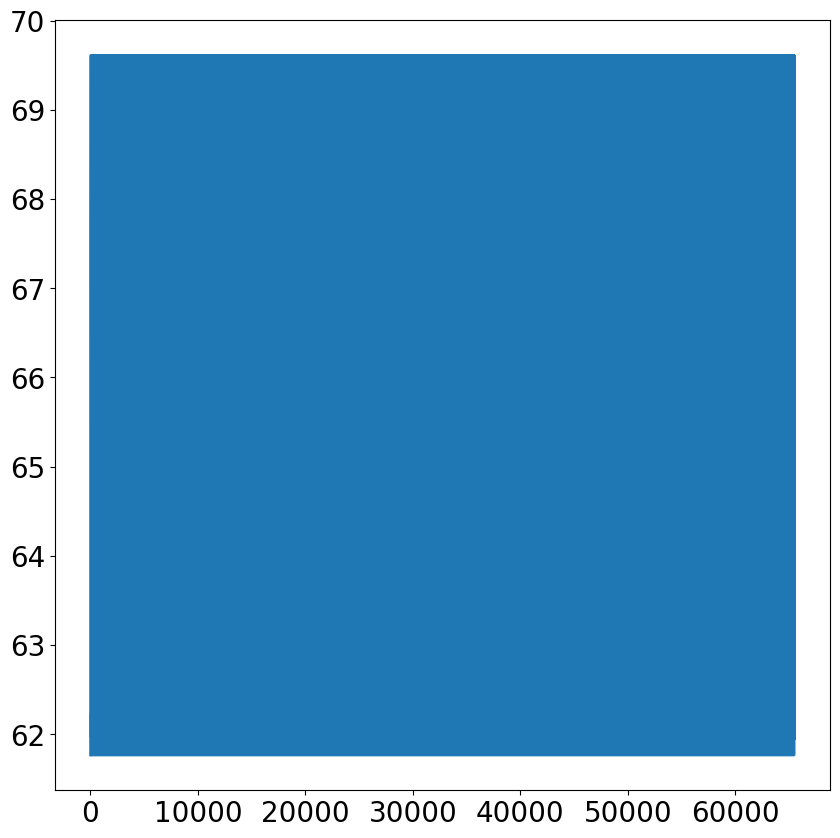

In [158]:
plt.plot(spec_noise_masked_corr)
plt.show()
plt.plot(scallop_model)
plt.show()

In [168]:
power_sqmod = np.abs(power_upchan)**2
I_upchan = np.swapaxes(np.nansum(power_sqmod, axis=0), 0, 1)

In [169]:
print(I_upchan)

[[  0.         0.         0.       ...   0.         0.         0.      ]
 [  0.         0.         0.       ...   0.         0.         0.      ]
 [  0.         0.         0.       ...   0.         0.         0.      ]
 ...
 [181.97719   13.555801 130.17896  ...  76.46293  101.733795 432.54276 ]
 [350.81998   63.507637 204.6906   ... 231.57253   41.84034  438.57562 ]
 [185.28053  142.88914   68.59377  ... 211.18008   84.20425  190.71126 ]]


In [170]:
I_upchan_corrected = np.zeros_like(I_upchan)
print(I_upchan_corrected.shape)

(65536, 187)


In [171]:
for time_bin in range(I_upchan_corrected.shape[1]):
    I_upchan_corrected[:, time_bin] = I_upchan[:, time_bin]/scallop_model
    
I_upchan_corrected = bandpasscorr_channel(I_upchan_corrected, off_pulse_idx)

In [172]:
print(I_upchan_corrected.shape)

(65536, 187)


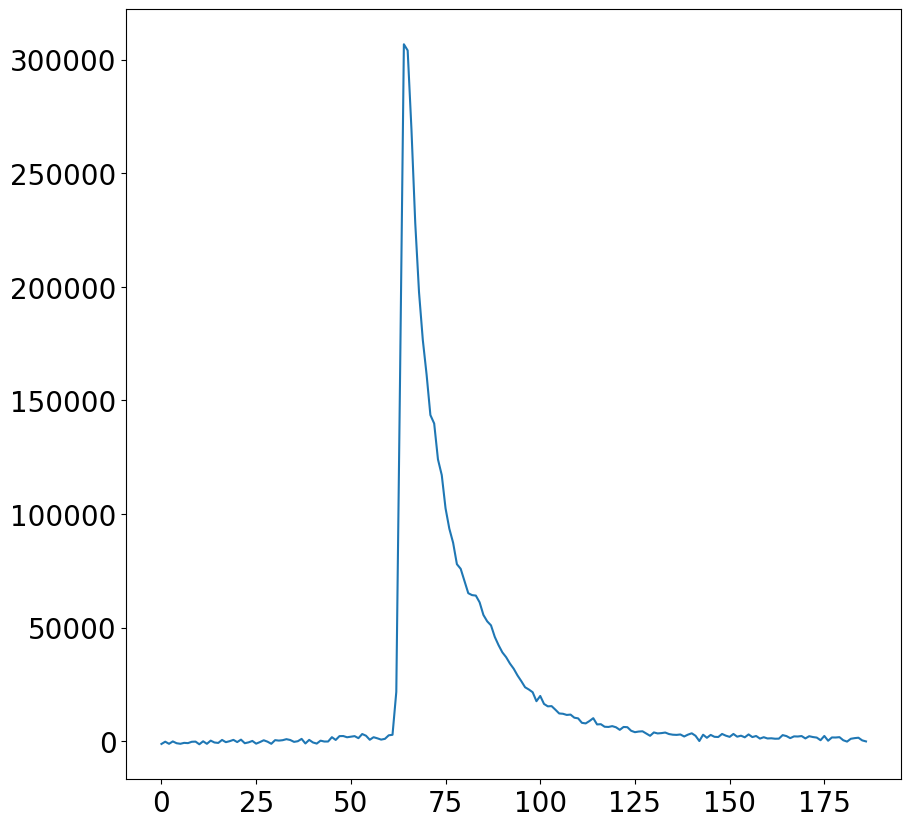

In [173]:
plt.plot(np.nansum(I_upchan_corrected, axis=0))

In [174]:
print(I_upchan_corrected.shape)

(65536, 187)


In [1]:
from lmfit import minimize, Parameters, fit_report, Model, Minimizer, report_fit

ModuleNotFoundError: No module named 'lmfit'

Frequency resolution is 0.00610 MHz
Masking where the array = 0


100%|██████████| 655/655 [00:00<00:00, 1448.21it/s]


Could not fit a Lorentzian
err 0.039103094350288754
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 34
    # data points      = 982
    # variables        = 3
    chi-square         = 432.455793
    reduced chi-square = 0.44173217
    Akaike info crit   = -799.349199
    Bayesian info crit = -784.680425
[[Variables]]
    gamma1:  1.96152081 +/- 3.26663387 (166.54%) (init = 0.2)
    m1:      0.26471037 +/- 0.18995637 (71.76%) (init = 1)
    c:       0.07683630 +/- 0.10466699 (136.22%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(m1, c)      = -0.9917
    C(gamma1, c)  = -0.9533
    C(gamma1, m1) = +0.9241
None


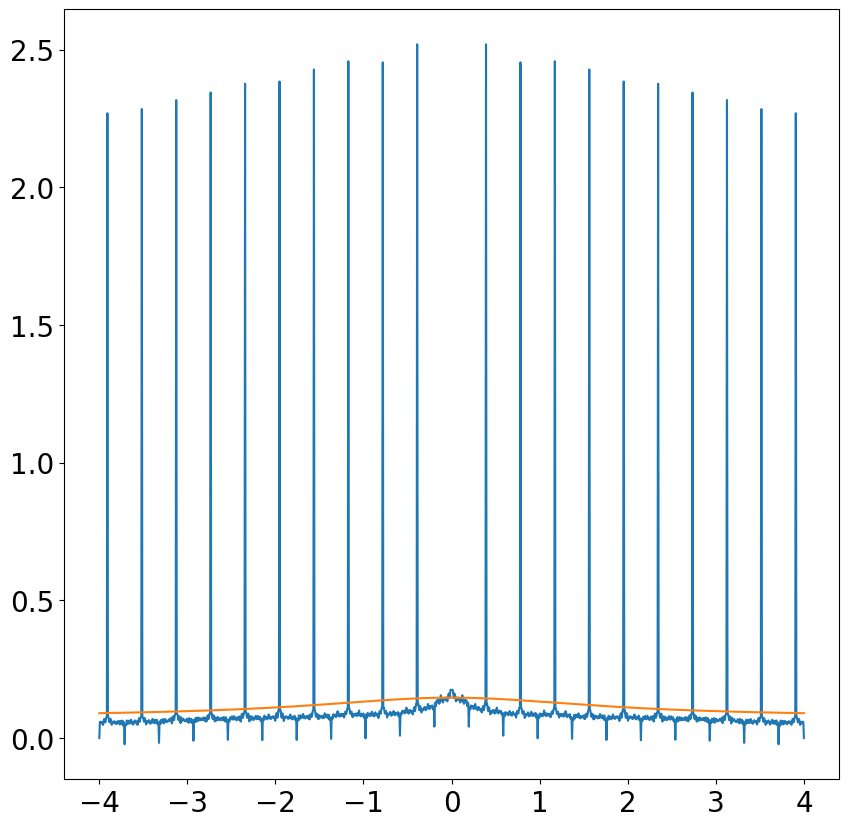

In [181]:
acf_res = acf_scint_plot(I_upchan_corrected,power_freqids,power_freqs,[55,125],lagrange_for_fit=0.01,diagnostic_plots=False,maxlag=4,offspec_mean=np.nanmean(I_upchan_corrected[:, 0:50]))
plt.close()


lagrange_for_fit=3
f_res=0.39101/(fftsize//downfreq)

acf=acf_res[0]
lag=acf_res[1]
acf_fit=acf[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]
lag_fit=lag[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]

#compute the ACF correlated errors
acf_half = acf[len(acf)//2:]
var_f = np.ones(len(acf_half)) / (len(acf_half))
var_f[1:] *= 1 + 2 * np.cumsum(acf_half[0:-1] ** 2)
f_errors = np.sqrt(var_f)
print("err",f_errors[0])

f_errors_full = np.concatenate((f_errors[::-1],f_errors))
acf_fit_errors=f_errors_full[int(len(acf)/2.)-int(lagrange_for_fit/f_res):int(len(acf)/2.)+int(lagrange_for_fit/f_res)]

params = Parameters()
params.add('gamma1', value = 0.2, min= 0.00001, max = 100)
params.add('m1', value = 1, min = -100, max = 100)
params.add('c',value=0,min=-100,max=100)

fit = Minimizer(lorentz_withc_min, params, fcn_args=(lag_fit,acf_fit,np.sqrt(acf_fit_errors)))
result_acf = fit.minimize()
print(report_fit(result_acf))

plt.plot(lag,acf)
plt.plot(lag,lorentz_w_c(lag,result_acf.params['gamma1'],result_acf.params['m1'],result_acf.params['c']))
plt.show()         

In [133]:
spec_mask = np.ma.masked_where(I_upspec_corr==0, I_upspec_corr)

In [134]:
spec_acf = autocorr_midx(I_upspec_corrected, v=spec_mask, zerolag=False)

NameError: name 'I_upspec_corrected' is not defined

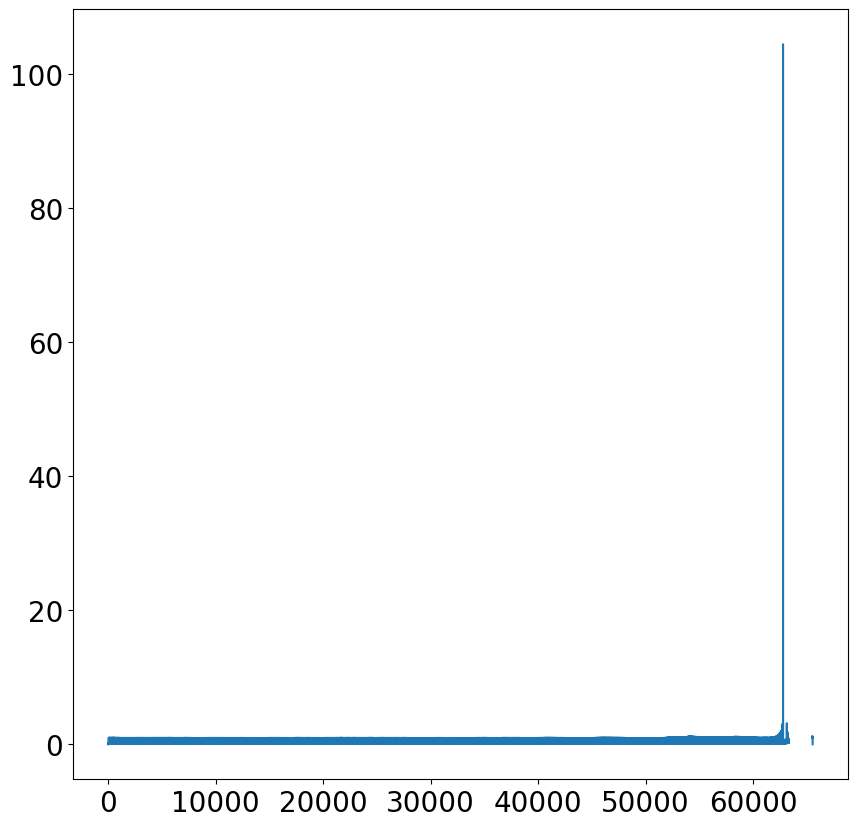

In [73]:
plt.plot(spec_acf)

In [74]:
spec_acf = np.concatenate((spec_acf[::-1], spec_acf))

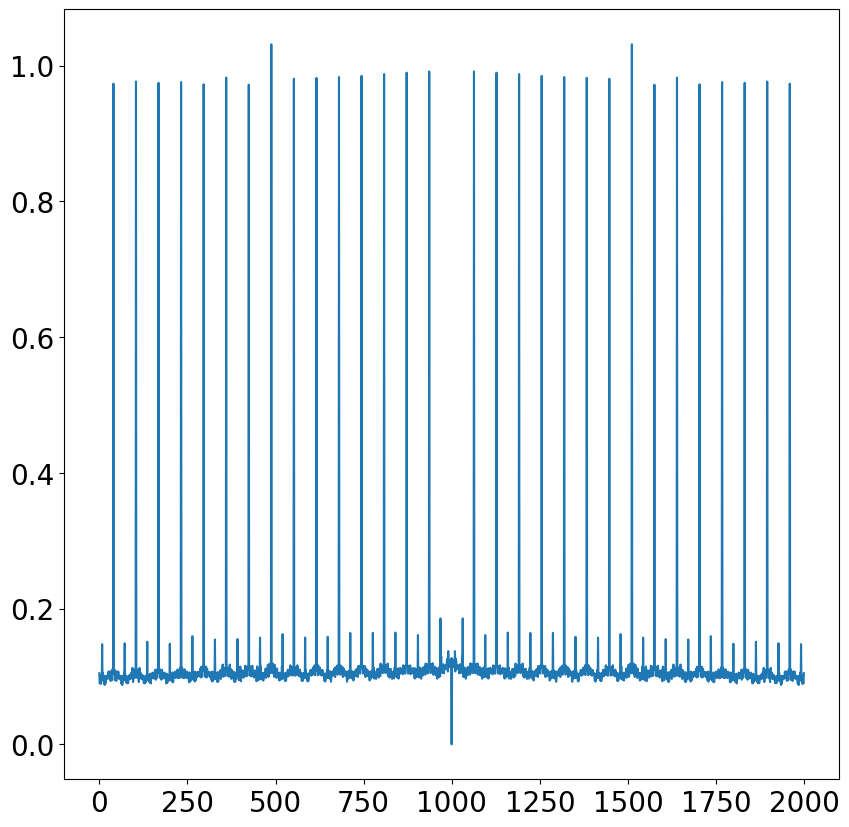

In [78]:
plt.plot(spec_acf[len(spec_acf)//2-1000:len(spec_acf)//2+1000])